# Backus–Gilbert Admissible Regions: Multi-$N_d$ Comparison

## Purpose

This is a **companion notebook** to `bg_with_errors_minkowski.ipynb`. It does not replace that
notebook; it calls the same mathematical pipeline but loops over a list of data-dimension values
$N_d \in \{5, 10, 20, 50, 100\}$ and collects results for side-by-side comparison.

The central question is:

> How does the **admissible property set** $\mathcal{U} \subseteq \tilde{\mathbf{p}} + H\mathcal{B} + X^\star\mathcal{V}_\mathcal{D}$ shrink (or not) as we increase the number of data $N_d$?

## Fair Comparison Design

When varying $N_d$, two things must be kept constant to ensure a fair experiment:

1. **Noise model**: The per-datum noise level $\sigma_d$ is fixed through the RMS clean-data
   amplitude, which is computed consistently relative to each operator's output norm (rather than
   fitted to the particular realised noise draw).

2. **Confidence calibration**: The data-confidence ellipsoid uses a $\chi^2_{N_d, 1-\beta}$
   quantile at a fixed probability level $1-\beta$, so increases in $N_d$ naturally grow the
   chi-square radius as a consequence of the Gaussian model, rather than being inflated by the
   analyst to cover a specific noise sample.

Under this design, any change in the admissible set when $N_d$ varies comes entirely from the
**operator geometry** (model-leakage term $H$, estimator $X^\star$) and the **dimension-scaling** of
the chi-square confidence geometry, not from unmodelled changes to the uncertainty specification.

## Interpretation Caveat

More data does not guarantee that every directional width shrinks monotonically with $N_d$.
Even under a nested-kernel design and fair uncertainty calibration, individual widths can show
small non-monotone steps because the admissible region depends on operator geometry, the chosen
support directions, and the sampled polyhedral approximation. The comparison is therefore best
interpreted through the overall region geometry and the net tightening from smaller to larger $N_d$.

## Kernel consistency across $N_d$

The sensitivity kernels are drawn from the same `NormalModesProvider` with a **fixed random
state**. The `NormalModesProvider` generates kernels in a reproducible order, so the first $N_d$
kernels for $N_d = 5$ are a strict prefix of the first $N_d = 10$ kernels.  This "nested"
design means an extra 5 data points for $N_d = 10$ are genuinely *additional* information —
not a different random draw of 10 kernels from the same pool.


In [1]:
# =============================================================================
# IMPORTS
# =============================================================================
from intervalinf import IntervalDomain, Lebesgue, Function
from intervalinf import (
    IntegrationConfig, ParallelConfig,
    LebesgueIntegrationConfig, LebesgueParallelConfig,
)
from intervalinf.providers import NormalModesProvider, BumpFunctionProvider
from intervalinf.operators import SOLAOperator

from pygeoinf import EuclideanSpace, LinearOperator
from pygeoinf.convex_analysis import BallSupportFunction, EllipsoidSupportFunction, SupportFunction
from pygeoinf.linear_solvers import CholeskySolver
from pygeoinf.subsets import HalfSpace, PolyhedralSet

import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.stats import chi2

print("All imports successful.")


All imports successful.


## Top-Level Configuration

Edit this cell to change the experiment parameters. All helper functions read from this cell, so modifying values here automatically propagates through the whole notebook.


In [2]:
# =============================================================================
# TOP-LEVEL CONFIGURATION  — edit here to change experiment parameters
# =============================================================================

# Data dimensions to compare.  The N_d values must be strictly positive integers.
# The NormalModesProvider uses them in a nested fashion: N_d=10 contains all
# kernels from N_d=5 as a strict prefix.
N_d_values = [5, 10, 20, 50, 100]

# Number of property targets (fixed throughout; property space R^{N_p})
N_p = 2

# Number of support-function directions sampled to build the polyhedral outer
# approximation of each admissible region.
N_theta = 50

# Per-datum noise level expressed as a fraction of the RMS clean-data amplitude.
# Keeping this fixed across N_d ensures the noise model is consistent.
noise_fraction = 0.10

# Probabilistic confidence level for the data-confidence ellipsoid.
# chi-square quantile chi2(N_d, confidence_level) is used so that larger N_d
# naturally reflects the geometry of the Gaussian model, not manual tuning.
confidence_level = 0.95

# Fixed random seed for kernel generation and noise draws.
# Using the same seed for the NormalModesProvider guarantees nested kernels.
random_seed = 2

# Integration resolution
integration_n_points = 500    # Lebesgue integration grid
sola_n_points = 1000          # SOLA operator integration grid

# Parallelism
n_jobs = 12

# Property kernel settings (match the single-case notebook)
property_bump_width = 0.3
property_centers = np.array([0.25, 0.75])

# Model prior: radius is set to 1.05 * || m_bar - m_0 || inside build_prior_and_confidence()
prior_radius_factor = 1.05

# Figure output folder for any optional per-case plots
figures_folder = "bg_with_errors_minkowski_multi_nd_figures"
os.makedirs(figures_folder, exist_ok=True)

print("Configuration loaded:")
print(f"  N_d_values:         {N_d_values}")
print(f"  N_theta:            {N_theta}")
print(f"  noise_fraction:     {noise_fraction}")
print(f"  confidence_level:   {confidence_level:.0%}")
print(f"  random_seed:        {random_seed}")
print(f"  property_centers:   {property_centers}")


Configuration loaded:
  N_d_values:         [5, 10, 20, 50, 100]
  N_theta:            50
  noise_fraction:     0.1
  confidence_level:   95%
  random_seed:        2
  property_centers:   [0.25 0.75]


## Helper Functions — Spaces, Operators, and Configuration

The next cells define modular helpers that wrap each stage of the single-case pipeline.
Each helper is a pure function that takes only explicit arguments and returns explicit results,
making it easy to call inside a loop over `N_d_values` in Phase 2.

### Stage 1 — Build Spaces and Operators (`build_spaces_and_operators`)

Creates `M` ($L^2([0,1])$), `D` ($\mathbb{R}^{N_d}$), `P` ($\mathbb{R}^{N_p}$), the forward
operator `G` (SOLA with normal-modes kernels), and the property operator `T` (SOLA with bump kernels).

The `random_state` parameter is the same for all `N_d` values so that the first $N_d$ kernels are
a nested prefix — an increase in $N_d$ adds new kernels rather than replacing old ones.


In [3]:
# =============================================================================
# HELPER 1 — Spaces and Operators
# =============================================================================

def build_integration_and_parallel_configs(
    lebesgue_n_points: int = 500,
    sola_n_points: int = 1000,
    n_jobs: int = 12,
):
    """Return shared integration and parallel configuration objects.

    These are constructed once and shared across all N_d cases to keep the
    numerical integration settings consistent.

    Args:
        lebesgue_n_points: Grid size for Lebesgue space inner products and dual maps.
        sola_n_points: Grid size for SOLA operator forward/adjoint evaluations.
        n_jobs: Number of parallel workers (-1 = all cores).

    Returns:
        Tuple (lebesgue_integration_cfg, sola_integration_cfg, parallel_cfg).
    """
    lebesgue_cfg = LebesgueIntegrationConfig(
        inner_product=IntegrationConfig(method='simpson', n_points=lebesgue_n_points),
        dual=IntegrationConfig(method='simpson', n_points=lebesgue_n_points),
        general=IntegrationConfig(method='simpson', n_points=lebesgue_n_points),
    )
    sola_cfg = IntegrationConfig(method='simpson', n_points=sola_n_points)
    par_cfg = ParallelConfig(enabled=True, n_jobs=n_jobs)
    return lebesgue_cfg, sola_cfg, par_cfg


def build_spaces_and_operators(
    N_d: int,
    N_p: int,
    lebesgue_cfg: LebesgueIntegrationConfig,
    sola_cfg: IntegrationConfig,
    par_cfg: ParallelConfig,
    property_centers: np.ndarray,
    property_bump_width: float,
    random_state: int = 2,
):
    """Build model, data, property spaces and forward/property operators.

    The NormalModesProvider is constructed with *random_state* fixed so that
    the first N_d sensitivity kernels are a strict prefix of any larger N_d
    run.  This guarantees a nested, "more data" comparison across N_d values.

    Args:
        N_d: Number of data (dimension of data space D = R^{N_d}).
        N_p: Number of property targets (dimension of property space P = R^{N_p}).
        lebesgue_cfg: LebesgueIntegrationConfig for M.
        sola_cfg: IntegrationConfig for SOLA operators.
        par_cfg: ParallelConfig for SOLA operators.
        property_centers: Array of shape (N_p,) with bump-kernel centre positions.
        property_bump_width: Width parameter for BumpFunctionProvider.
        random_state: Seed for NormalModesProvider (kept fixed across N_d calls).

    Returns:
        Dict with keys: 'M', 'D', 'P', 'G', 'T', 'function_domain'.
    """
    function_domain = IntervalDomain(0, 1)

    M = Lebesgue(
        0,
        function_domain,
        basis=None,
        integration_config=lebesgue_cfg,
        parallel_config=par_cfg,
    )
    D = EuclideanSpace(N_d)
    P = EuclideanSpace(N_p)

    normal_modes_provider = NormalModesProvider(
        M,
        n_modes_range=(1, 50),
        coeff_range=(-5, 5),
        gaussian_width_percent_range=(1, 5),
        freq_range=(0.1, 20),
        random_state=random_state,
    )

    G = SOLAOperator(
        M, D,
        kernels=normal_modes_provider,
        cache_kernels=True,
        integration_config=sola_cfg,
    )

    target_provider = BumpFunctionProvider(
        M, centers=property_centers, default_width=property_bump_width,
    )
    T = SOLAOperator(
        M, P,
        kernels=target_provider,
        cache_kernels=True,
        integration_config=sola_cfg,
    )

    return {'M': M, 'D': D, 'P': P, 'G': G, 'T': T, 'function_domain': function_domain}


print("build_spaces_and_operators defined.")


build_spaces_and_operators defined.


### Stage 2 — True Model, Noise Calibration, and Synthetic Data (`build_true_model_and_noise`)

The true model is

$$
\bar{m}(x) = \exp\!\left(-\frac{(x-0.5)^2}{0.5^2}\right)\sin(5\pi x) + x,
$$

the same formula used in `bg_with_errors_minkowski.ipynb` and `dli.ipynb`.

The noise level $\sigma_d$ is set from the RMS clean-data amplitude:

$$
\sigma_d = \texttt{noise\_fraction} \times \frac{\|\bar{\mathbf{d}}\|_2}{\sqrt{N_d}},
$$

so that the **per-datum noise fraction stays constant** as $N_d$ grows.  This prevents the noise
model from growing simply because there are more data.


In [4]:
# =============================================================================
# HELPER 2 — True Model, Noise, and Synthetic Data
# =============================================================================

def build_true_model_and_noise(
    M: Lebesgue,
    G: SOLAOperator,
    N_d: int,
    noise_fraction: float,
    random_seed: int = 42,
):
    """Construct the true model, calibrate noise, and draw synthetic observations.

    The per-datum noise level is calibrated from the RMS clean-data amplitude
    so that sigma_d is independent of N_d in expectation — only the *total*
    noise power grows with N_d, not the per-datum level.

    $$
    \\sigma_d = \\texttt{noise\\_fraction} \\times \\frac{\\|\\bar{\\mathbf{d}}\\|_2}{\\sqrt{N_d}}
    $$

    Args:
        M: Model Hilbert space L^2([0, 1]).
        G: Forward SOLA operator M -> D.
        N_d: Number of data (must match D = G.codomain).
        noise_fraction: Fraction of RMS clean-data amplitude used as per-datum sigma.
        random_seed: NumPy random seed for reproducibility of the noise draw.

    Returns:
        Dict with keys:
            'm_bar': true model Function,
            'd_bar': clean data array of shape (N_d,),
            'd_tilde': noisy data array of shape (N_d,),
            'noise_vector': drawn noise array of shape (N_d,),
            'sigma_d': per-datum noise standard deviation (float),
            'signal_rms': RMS of clean data (float).
    """
    m_bar = Function(
        M,
        evaluate_callable=lambda x: (
            np.exp(-((x - 0.5) / 0.5) ** 2) * np.sin(5 * np.pi * x) + x
        ),
    )

    d_bar = G(m_bar)
    signal_rms = np.linalg.norm(d_bar) / np.sqrt(N_d)
    sigma_d = noise_fraction * signal_rms

    rng = np.random.default_rng(random_seed)
    noise_vector = rng.normal(0.0, sigma_d, N_d)
    d_tilde = d_bar + noise_vector

    return {
        'm_bar': m_bar,
        'd_bar': d_bar,
        'd_tilde': d_tilde,
        'noise_vector': noise_vector,
        'sigma_d': sigma_d,
        'signal_rms': signal_rms,
    }


print("build_true_model_and_noise defined.")


build_true_model_and_noise defined.


### Stage 3 — Model Prior Ball and Data-Confidence Ellipsoid (`build_prior_and_confidence`)

The model prior ball is centred at $m_0(x) = x$ with radius

$$
r = \texttt{prior\_radius\_factor} \times \|\bar{m} - m_0\|_\mathcal{M}.
$$

The data-confidence ellipsoid is isotropic with covariance $\mathbf{C}_\mathcal{D} = \sigma_d^2 \mathbf{I}$ and confidence level $1-\beta$ through the $\chi^2_{N_d}$ quantile:

$$
s^2 = \tfrac{1}{2}\chi^2_{N_d,\,1-\beta}, \qquad
r_\mathcal{V} = \sigma_d\sqrt{\chi^2_{N_d,\,1-\beta}}.
$$

This is the "fair calibration" property: the ellipsoid radius $r_\mathcal{V}$ is set by the
Gaussian model and the confidence level, not by the realised noise sample.


In [5]:
# =============================================================================
# HELPER 3 — Model Prior Ball and Data-Confidence Ellipsoid
# =============================================================================

def _scalar_op(space, scale):
    """Return a self-adjoint scalar-multiple-of-identity LinearOperator on *space*."""
    return LinearOperator.self_adjoint(space, lambda v: scale * v)


def build_prior_and_confidence(
    M: Lebesgue,
    D: EuclideanSpace,
    m_bar: Function,
    sigma_d: float,
    N_d: int,
    confidence_level: float,
    prior_radius_factor: float = 1.05,
):
    """Build the model prior ball and the data-confidence ellipsoid.

    The model radius $r$ is set relative to the true model so that the prior
    ball tightly contains $\\bar{m}$:

    $$
    r = \\texttt{prior\\_radius\\_factor} \\times \\|\\bar{m} - m_0\\|_\\mathcal{M}.
    $$

    The ellipsoid uses a chi-square confidence rule:

    $$
    s^2 = \\tfrac{1}{2}\\chi^2_{N_d, 1-\\beta},
    \\qquad r_\\mathcal{V} = \\sigma_d \\sqrt{\\chi^2_{N_d, 1-\\beta}}.
    $$

    Args:
        M: Model Hilbert space L^2([0, 1]).
        D: Data Euclidean space R^{N_d}.
        m_bar: True model Function (used only to set the prior radius).
        sigma_d: Per-datum noise standard deviation.
        N_d: Data dimension (used in chi-square quantile with df=N_d).
        confidence_level: Probability level 1-beta for the chi-square quantile.
        prior_radius_factor: Multiplier on ||m_bar - m_0|| for model ball radius.

    Returns:
        Dict with keys:
            'model_prior_support': BallSupportFunction around m_0(x)=x,
            'data_conf_ellipsoid': EllipsoidSupportFunction on D,
            's_confidence': chi-square scale s (float),
            'r_data_conf': Euclidean radius r_V of the ellipsoid (float),
            'model_radius': model ball radius r (float),
            'm_0': centre Function of the model ball.
    """
    m_0 = Function(M, evaluate_callable=lambda x: x)
    model_radius = prior_radius_factor * M.norm(M.subtract(m_bar, m_0))
    model_prior_support = BallSupportFunction(M, m_0, model_radius)

    s_confidence = np.sqrt(0.5 * chi2.ppf(confidence_level, df=N_d))
    r_data_conf = s_confidence * np.sqrt(2.0) * sigma_d

    A_op = _scalar_op(D, 1.0 / (2.0 * sigma_d ** 2))       # A   = C_d^{-1}/2
    A_inv_op = _scalar_op(D, 2.0 * sigma_d ** 2)            # A^{-1} = 2 C_d
    A_inv_sqrt = _scalar_op(D, np.sqrt(2.0) * sigma_d)      # A^{-1/2}

    data_conf_ellipsoid = EllipsoidSupportFunction(
        D,
        center=D.zero,
        radius=s_confidence,
        shape_operator=A_op,
        inverse_operator=A_inv_op,
        inverse_sqrt_operator=A_inv_sqrt,
    )

    return {
        'model_prior_support': model_prior_support,
        'data_conf_ellipsoid': data_conf_ellipsoid,
        's_confidence': s_confidence,
        'r_data_conf': r_data_conf,
        'model_radius': model_radius,
        'm_0': m_0,
    }


print("build_prior_and_confidence defined.")


build_prior_and_confidence defined.


### Stage 4 — Optimal Estimator $X^\star$ (`build_optimal_estimator`)

The optimal estimator is

$$
X^\star = \mathcal{T}\,G^*\!\bigl(GG^* + \alpha\,\mathbf{C}_\mathcal{D}\bigr)^{-1},
\qquad \alpha = \frac{2s^2}{r^2}.
$$

Built using the pygeoinf operator algebra — no explicit Gram matrix assembly needed.


In [6]:
# =============================================================================
# HELPER 4 — Optimal Linear Estimator X*
# =============================================================================

def build_optimal_estimator(
    T: SOLAOperator,
    G: SOLAOperator,
    D: EuclideanSpace,
    sigma_d: float,
    s_confidence: float,
    model_radius: float,
    par_cfg: ParallelConfig,
):
    """Construct the optimal BG estimator operator X* : D -> P.

    $$
    X^\\star = \\mathcal{T} G^* (GG^* + \\alpha \\mathbf{C}_\\mathcal{D})^{-1},
    \\qquad \\alpha = 2s^2 / r^2.
    $$

    Uses pygeoinf operator algebra.  A ``CholeskySolver`` is appropriate for the
    small, dense, SPD operator on D; alternative solvers from
    ``pygeoinf.linear_solvers`` can be substituted without changing the maths.

    Args:
        T: Property SOLA operator M -> P.
        G: Forward SOLA operator M -> D.
        D: Data Euclidean space R^{N_d}.
        sigma_d: Per-datum noise standard deviation.
        s_confidence: chi-square confidence scale s (from build_prior_and_confidence).
        model_radius: Model prior ball radius r (from build_prior_and_confidence).
        par_cfg: ParallelConfig passed to the Cholesky solver.

    Returns:
        Dict with keys:
            'X_star_operator': optimal estimator LinearOperator D -> P,
            'alpha': regularisation parameter (float),
            'C_d_operator': covariance operator on D (sigma_d^2 * I).
    """
    C_d_operator = _scalar_op(D, sigma_d ** 2)
    alpha = 2.0 * s_confidence ** 2 / model_radius ** 2

    regularized_data_operator = G @ G.adjoint + alpha * C_d_operator

    solver = CholeskySolver(parallel=True, n_jobs=par_cfg.n_jobs)
    regularized_inverse = solver(regularized_data_operator)

    X_star_operator = T @ G.adjoint @ regularized_inverse

    return {
        'X_star_operator': X_star_operator,
        'alpha': alpha,
        'C_d_operator': C_d_operator,
    }


print("build_optimal_estimator defined.")


build_optimal_estimator defined.


### Stage 5 — Admissible Region (`build_admissible_support`)

The admissible property set satisfies

$$
\mathcal{U} \subseteq \tilde{\mathbf{p}} + H\mathcal{B} + X^\star\mathcal{V}_\mathcal{D},
$$

where $H = \mathcal{T} - X^\star G$.  The support function is assembled via the
`pygeoinf.convex_analysis` algebra; polyhedral outer approximation samples $N_\theta$ unit
directions to form the halfspace intersection $\mathcal{U}_\theta$.


In [7]:
# =============================================================================
# HELPER 5 — Admissible Support Function and Polyhedral Region
# =============================================================================

def build_admissible_support(
    P: EuclideanSpace,
    T: SOLAOperator,
    G: SOLAOperator,
    X_star_operator,
    model_prior_support: BallSupportFunction,
    data_conf_ellipsoid: EllipsoidSupportFunction,
    d_tilde: np.ndarray,
    N_theta: int = 200,
):
    """Build the admissible support function and its polyhedral outer approximation.

    The admissible set is

    $$
    \\mathcal{U} \\subseteq \\tilde{\\mathbf{p}} + H\\mathcal{B} + X^\\star\\mathcal{V}_\\mathcal{D},
    $$

    where $H = \\mathcal{T} - X^\\star G$.

    The support function is assembled declaratively using pygeoinf.convex_analysis algebra:
    - ``SupportFunction.point`` for the estimated property point $\\tilde{\\mathbf{p}}$,
    - ``.image(H_operator)`` for the model-uncertainty contribution (adjoint pullback internal),
    - ``.image(X_star_operator)`` for the data-uncertainty contribution.

    $N_\\theta$ uniformly-spaced unit directions sample the polyhedral outer approximation.

    Args:
        P: Property Euclidean space R^{N_p}.
        T: Property SOLA operator M -> P.
        G: Forward SOLA operator M -> D.
        X_star_operator: Optimal estimator D -> P.
        model_prior_support: BallSupportFunction for model ball B.
        data_conf_ellipsoid: EllipsoidSupportFunction for data-confidence set V_D.
        d_tilde: Noisy data vector, shape (N_d,).
        N_theta: Number of halfspace directions for polyhedral approximation.

    Returns:
        Dict with keys:
            'p_t': estimated property np.ndarray of shape (N_p,),
            'H_operator': residual operator T - X*G,
            'admissible_support': SupportFunction for the Minkowski sum,
            'admissible_region': PolyhedralSet outer approximation,
            'model_support_image': SupportFunction for H(B),
            'data_support_image': SupportFunction for X*(V_D).
    """
    p_t = X_star_operator(d_tilde)
    H_operator = T - X_star_operator @ G

    admissible_support = (
        SupportFunction.point(P, p_t)
        + model_prior_support.image(H_operator)
        + data_conf_ellipsoid.image(X_star_operator)
    )

    angles = np.linspace(0, 2 * np.pi, N_theta, endpoint=False)
    halfspaces = [
        HalfSpace(
            P,
            normal_vector=np.array([np.cos(t), np.sin(t)]),
            offset=admissible_support(np.array([np.cos(t), np.sin(t)])),
        )
        for t in angles
    ]
    admissible_region = PolyhedralSet(P, half_spaces=halfspaces)

    model_support_image = model_prior_support.image(H_operator)
    data_support_image = data_conf_ellipsoid.image(X_star_operator)

    return {
        'p_t': p_t,
        'H_operator': H_operator,
        'admissible_support': admissible_support,
        'admissible_region': admissible_region,
        'model_support_image': model_support_image,
        'data_support_image': data_support_image,
    }


print("build_admissible_support defined.")


build_admissible_support defined.


### Top-Level Runner (`run_single_nd_case`)

Chains all five stages into one call that returns a structured result dictionary. Phase 2 will call this inside a loop over `N_d_values`.


In [8]:
# =============================================================================
# TOP-LEVEL SINGLE-CASE RUNNER
# =============================================================================

def run_single_nd_case(
    N_d: int,
    *,
    N_p: int = 2,
    N_theta: int = 200,
    noise_fraction: float = 0.10,
    confidence_level: float = 0.95,
    random_seed: int = 2,
    prior_radius_factor: float = 1.05,
    property_centers: np.ndarray | None = None,
    property_bump_width: float = 0.3,
    lebesgue_n_points: int = 500,
    sola_n_points: int = 1000,
    n_jobs: int = 12,
    verbose: bool = True,
):
    """Run the full BG admissible-region pipeline for a single N_d value.

    This function chains all five helper stages (spaces/operators, noise,
    prior/confidence, estimator, admissible region) and returns a flat
    result dictionary suitable for storing per-N_d outputs.

    The same ``random_seed`` is used for both the NormalModesProvider
    (kernel generation) and the noise draw, giving nested and reproducible
    results across N_d values.

    Args:
        N_d: Number of data dimensions.
        N_p: Number of property targets.
        N_theta: Directions for polyhedral approximation of admissible region.
        noise_fraction: Fraction of RMS signal amplitude for per-datum noise.
        confidence_level: Chi-square confidence level for data ellipsoid.
        random_seed: Shared seed for kernel generation and noise draw. Using the
            same seed across calls to run_single_nd_case(N_d) ensures kernels are
            a nested prefix.
        prior_radius_factor: Multiplier on ||m_bar - m_0|| for model ball radius.
        property_centers: Array of shape (N_p,) with bump centre positions.
            Defaults to [0.25, 0.75].
        property_bump_width: Width for BumpFunctionProvider.
        lebesgue_n_points: Grid size for Lebesgue inner products.
        sola_n_points: Grid size for SOLA operator evaluations.
        n_jobs: Number of parallel workers.
        verbose: Print a brief diagnostic summary when True.

    Returns:
        Dict with all stage outputs merged, plus:
            'N_d': the data dimension,
            'p_bar': true property np.ndarray of shape (N_p,),
            'x_width': width of admissible region in x-direction (p_1),
            'y_width': width of admissible region in y-direction (p_2).
    """
    if property_centers is None:
        property_centers = np.array([0.25, 0.75])

    # Stage 1
    lebesgue_cfg, sola_cfg, par_cfg = build_integration_and_parallel_configs(
        lebesgue_n_points=lebesgue_n_points,
        sola_n_points=sola_n_points,
        n_jobs=n_jobs,
    )
    spaces = build_spaces_and_operators(
        N_d=N_d, N_p=N_p,
        lebesgue_cfg=lebesgue_cfg, sola_cfg=sola_cfg, par_cfg=par_cfg,
        property_centers=property_centers,
        property_bump_width=property_bump_width,
        random_state=random_seed,
    )
    M, D, P, G, T = spaces['M'], spaces['D'], spaces['P'], spaces['G'], spaces['T']

    # Stage 2
    noise_data = build_true_model_and_noise(
        M=M, G=G, N_d=N_d,
        noise_fraction=noise_fraction,
        random_seed=random_seed,
    )
    m_bar = noise_data['m_bar']
    sigma_d = noise_data['sigma_d']

    # Stage 3
    prior_conf = build_prior_and_confidence(
        M=M, D=D, m_bar=m_bar,
        sigma_d=sigma_d, N_d=N_d,
        confidence_level=confidence_level,
        prior_radius_factor=prior_radius_factor,
    )

    # Stage 4
    estimator = build_optimal_estimator(
        T=T, G=G, D=D,
        sigma_d=sigma_d,
        s_confidence=prior_conf['s_confidence'],
        model_radius=prior_conf['model_radius'],
        par_cfg=par_cfg,
    )

    # Stage 5
    admissible = build_admissible_support(
        P=P, T=T, G=G,
        X_star_operator=estimator['X_star_operator'],
        model_prior_support=prior_conf['model_prior_support'],
        data_conf_ellipsoid=prior_conf['data_conf_ellipsoid'],
        d_tilde=noise_data['d_tilde'],
        N_theta=N_theta,
    )

    p_bar = T(m_bar)

    # Compute approximate widths for diagnostics
    sup = admissible['admissible_support']
    x_width = sup(np.array([1.0, 0.0])) + sup(np.array([-1.0, 0.0]))
    y_width = sup(np.array([0.0, 1.0])) + sup(np.array([0.0, -1.0]))

    if verbose:
        print(f"N_d={N_d:4d}  sigma_d={sigma_d:.4f}  r_V={prior_conf['r_data_conf']:.4f}"
              f"  alpha={estimator['alpha']:.4f}"
              f"  x_width={x_width:.4f}  y_width={y_width:.4f}")

    result = {
        'N_d': N_d,
        'p_bar': p_bar,
        'x_width': x_width,
        'y_width': y_width,
    }
    result.update(spaces)
    result.update(noise_data)
    result.update(prior_conf)
    result.update(estimator)
    result.update(admissible)
    return result


print("run_single_nd_case defined.")


run_single_nd_case defined.


## Result Containers

Initialise the dictionary that collects per-$N_d$ outputs from the Phase 2 loop. Stored here so that the downstream cells can reference `nd_results` regardless of whether the loop is about to be executed, has already been executed, or is being re-run after configuration changes.

In [9]:
# =============================================================================
# RESULT CONTAINER
# =============================================================================

# Keyed by N_d (int). Each value is the dict returned by run_single_nd_case().
# The Phase 2 loop below repopulates this dictionary whenever the comparison is run.
nd_results: dict[int, dict] = {}

print(f"nd_results initialised (currently empty, will hold keys: {N_d_values})")

nd_results initialised (currently empty, will hold keys: [5, 10, 20, 50, 100])


## Phase 2 — Multi-$N_d$ BG Pipeline Loop

The cell below runs `run_single_nd_case` for every `N_d` in `N_d_values` and stores
the full result dictionary in `nd_results`, keyed by `N_d`.

Each result contains all geometry objects needed for Phase 3 plotting and diagnostics:

| Key | Description |
|-----|-------------|
| `X_star_operator` | BG optimal estimator operator |
| `H_operator` | Residual spreading operator $H = \mathcal{T} - X^\star G$ |
| `admissible_support` | Support function of the admissible region |
| `admissible_region` | Polyhedral admissible set (`PolyhedralSet`) |
| `p_t` | Estimated property vector $\tilde{\mathbf{p}} = X^\star \tilde{\mathbf{d}}$ |
| `p_bar` | True property vector $\bar{\mathbf{p}} = \mathcal{T}\bar{m}$ |
| `sigma_d` | Per-datum noise standard deviation |
| `r_data_conf` | Radius of data-confidence ellipsoid |
| `alpha` | BG regularisation parameter |
| `x_width` | Width of admissible region in the $p_1$ direction |
| `y_width` | Width of admissible region in the $p_2$ direction |

A progress line is printed for each case. A validation cell follows to confirm correctness,
including that the true property `p_bar` lies inside each admissible region.

In [10]:
# =============================================================================
# PHASE 2 — MULTI-Nd LOOP
# =============================================================================
# Run the full BG admissible-region pipeline for each N_d in N_d_values.
# The same random_seed is passed to every call so that kernel generation is
# nested: the kernels for N_d=5 are a strict prefix of those for N_d=10, etc.
# This ensures fair comparisons — differences in admissible-region size reflect
# only the information gain from more data, not random kernel variation.

nd_results: dict[int, dict] = {}

print(f"{'N_d':>6}  {'sigma_d':>8}  {'r_V':>8}  {'alpha':>8}  {'x_width':>8}  {'y_width':>8}")
print("-" * 58)

for N_d in N_d_values:
    result = run_single_nd_case(
        N_d=N_d,
        N_p=N_p,
        N_theta=N_theta,
        noise_fraction=noise_fraction,
        confidence_level=confidence_level,
        random_seed=random_seed,
        prior_radius_factor=prior_radius_factor,
        property_centers=property_centers,
        property_bump_width=property_bump_width,
        lebesgue_n_points=integration_n_points,
        sola_n_points=sola_n_points,
        n_jobs=n_jobs,
        verbose=False,
    )
    nd_results[N_d] = result
    print(f"{N_d:>6}  {result['sigma_d']:>8.4f}  {result['r_data_conf']:>8.4f}"
          f"  {result['alpha']:>8.4f}  {result['x_width']:>8.4f}  {result['y_width']:>8.4f}")

print("\nAll cases complete.  nd_results keys:", sorted(nd_results.keys()))


   N_d   sigma_d       r_V     alpha   x_width   y_width
----------------------------------------------------------


     5    0.0390    0.1299   33.4543    2.3133    2.0447
    10    0.0286    0.1225   55.3227    2.2880    2.0505
    20    0.0303    0.1698   94.9203    2.1094    1.9998
    50    0.0293    0.2411  203.9953    1.1490    1.9204
   100    0.0270    0.3011  375.7540    0.4519    0.9477

All cases complete.  nd_results keys: [5, 10, 20, 50, 100]


In [11]:
# =============================================================================
# PHASE 2 VALIDATION
# =============================================================================
# Verify that nd_results is well-formed before Phase 3 proceeds.

_required_keys = [
    'X_star_operator', 'H_operator',
    'admissible_support', 'admissible_region',
    'p_t', 'p_bar',
    'sigma_d', 'r_data_conf', 'alpha',
    'x_width', 'y_width',
]

# 1. Exact N_d coverage
assert set(nd_results.keys()) == set(N_d_values), (
    f"nd_results keys {sorted(nd_results.keys())} do not match N_d_values {N_d_values}"
)
print(f"N_d coverage check        : PASS  {sorted(nd_results.keys())}")

# 2. Required keys present in every case
for N_d, res in nd_results.items():
    missing = [k for k in _required_keys if k not in res]
    assert not missing, f"N_d={N_d}: missing keys {missing}"
print("Required-key check        : PASS")

# 3. admissible_region is a PolyhedralSet for every case
for N_d, res in nd_results.items():
    region = res['admissible_region']
    assert isinstance(region, PolyhedralSet), f"N_d={N_d}: admissible_region is not a PolyhedralSet"
print("PolyhedralSet type check  : PASS")

# 4. p_bar lies inside the admissible region for every case
for N_d, res in nd_results.items():
    assert res['admissible_region'].is_element(res['p_bar']), (
        f"N_d={N_d}: p_bar not inside admissible_region — pipeline broken"
    )
print("p_bar containment check   : PASS")

# 5. Widths are strictly positive for all cases
for N_d, res in nd_results.items():
    assert res['x_width'] > 0, f"N_d={N_d}: x_width <= 0"
    assert res['y_width'] > 0, f"N_d={N_d}: y_width <= 0"
print("Width positivity check    : PASS")

print("\nAll Phase 2 validations passed.")

N_d coverage check        : PASS  [5, 10, 20, 50, 100]
Required-key check        : PASS
PolyhedralSet type check  : PASS
p_bar containment check   : PASS
Width positivity check    : PASS

All Phase 2 validations passed.


## Phase 3 — Absolute Overlay Plot and Diagnostics

This section plots all absolute admissible property sets on a single figure, one filled region per $N_d$ value, using a colour progression to distinguish cases. A concise per-case summary table is then printed, reporting noise level, data-confidence radius, regularisation parameter, and admissible-region widths so that the information gain from increasing $N_d$ can be seen at a glance.

In [12]:
# =============================================================================
# PHASE 3 — BOUNDARY HELPER: reconstruct a 2-D convex polygon from a support
# function by intersecting consecutive halfplane boundaries and filtering out
# any candidate vertex that violates any of the sampled halfplane constraints.
# =============================================================================

def region_boundary_xy(support_fn, n_angles: int = 400):
    """Reconstruct 2-D polygon boundary from a support function.

    Samples ``n_angles`` unit directions uniformly on [0, 2\u03c0), evaluates the
    support function for each direction, and then finds polygon vertices by
    solving each consecutive pair of halfplane boundary equations.

    A candidate vertex is accepted only if it satisfies **all** sampled
    halfplane inequalities ``n_k \u00b7 v \u2264 h_k + \u03b5``.  This ensures
    the returned polygon lies correctly inside the polyhedral approximation
    even when N_d is large or the support function has sharp features.
    Nearly-parallel pairs (|det| < 1e-10) are skipped.

    Parameters
    ----------
    support_fn : callable
        Support function accepting a 1-D numpy array of shape (2,).
    n_angles : int
        Number of uniformly sampled directions in [0, 2\u03c0).

    Returns
    -------
    xs, ys : np.ndarray
        Arrays of x- and y-coordinates forming a closed polygon path (the
        first vertex is repeated at the end).
    """
    import numpy as np

    thetas = np.linspace(0, 2 * np.pi, n_angles, endpoint=False)
    directions = np.column_stack([np.cos(thetas), np.sin(thetas)])  # (n_angles, 2)

    # Evaluate support values h_i = h(n_i)
    h_values = np.array([support_fn(d) for d in directions])  # (n_angles,)

    vertices_x = []
    vertices_y = []

    n = n_angles
    for i in range(n):
        j = (i + 1) % n
        n_i = directions[i]
        n_j = directions[j]
        h_i = h_values[i]
        h_j = h_values[j]

        # Solve the 2x2 system:
        #   n_i[0]*x + n_i[1]*y = h_i
        #   n_j[0]*x + n_j[1]*y = h_j
        A = np.array([[n_i[0], n_i[1]],
                      [n_j[0], n_j[1]]])
        det = A[0, 0] * A[1, 1] - A[0, 1] * A[1, 0]
        if abs(det) < 1e-10:
            continue  # nearly parallel halfplanes — skip
        b = np.array([h_i, h_j])
        v = np.linalg.solve(A, b)

        # Validate: v must lie inside *all* sampled halfplanes n_k . v <= h_k
        residuals = directions @ v - h_values  # (n_angles,), positive = violation
        if np.all(residuals <= 1e-9):
            vertices_x.append(v[0])
            vertices_y.append(v[1])

    if len(vertices_x) == 0:
        raise RuntimeError(
            "region_boundary_xy: no valid vertices found — check support function"
        )

    # Close the polygon
    vertices_x.append(vertices_x[0])
    vertices_y.append(vertices_y[0])

    return np.array(vertices_x), np.array(vertices_y)


print("region_boundary_xy defined.")

region_boundary_xy defined.


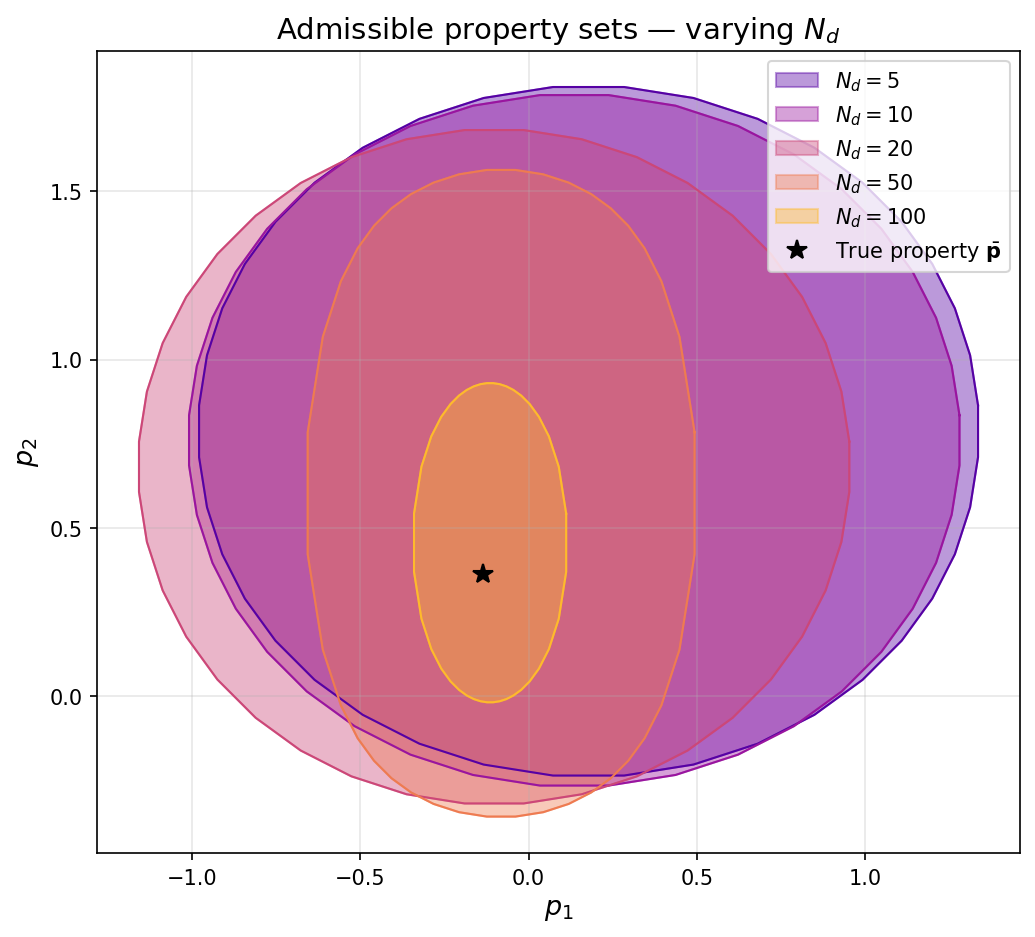

Figures saved to: bg_with_errors_minkowski_multi_nd_figures


In [13]:
# =============================================================================
# PHASE 3 — OVERLAY FIGURE
# =============================================================================
# Plot all absolute admissible property sets on one figure using a colour
# progression over N_d.  Large N_d produces a small, tight region; small N_d
# produces a wide region.  Drawing in ascending N_d order (large regions first)
# ensures smaller regions are visible on top.

import matplotlib.cm as mcm
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(7, 7), dpi=150)

# Build a colour map: N colours evenly spaced in [0.15, 0.85] of plasma.
# The *smallest* N_d gets the lightest colour (largest region).
cmap = mcm.plasma
n_cases = len(N_d_values)
color_positions = np.linspace(0.15, 0.85, n_cases)

for idx, N_d in enumerate(sorted(N_d_values)):          # ascending → large first
    color = cmap(color_positions[idx])
    support_fn = nd_results[N_d]['admissible_support']
    xs, ys = region_boundary_xy(support_fn, n_angles=40)
    ax.fill(xs, ys, alpha=0.40, color=color, label=f'$N_d = {N_d}$')
    ax.plot(xs, ys, color=color, linewidth=1.0)

# Mark the true property p_bar (identical across all cases)
p_bar = nd_results[N_d_values[0]]['p_bar']
ax.plot(*p_bar, 'k*', markersize=10, zorder=10, label=r'True property $\bar{\mathbf{p}}$')

ax.set_xlabel(r'$p_1$', fontsize=13)
ax.set_ylabel(r'$p_2$', fontsize=13)
ax.set_title(r'Admissible property sets — varying $N_d$', fontsize=14)
ax.legend(loc='upper right', fontsize=10)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(figures_folder, 'admissible_regions_multi_nd.png'),
            dpi=150, bbox_inches='tight')
plt.savefig(os.path.join(figures_folder, 'admissible_regions_multi_nd.pdf'),
            bbox_inches='tight')
plt.show()
print(f"Figures saved to: {figures_folder}")


In [14]:
# =============================================================================
# PHASE 3 — DIAGNOSTIC SUMMARY TABLE
# =============================================================================
# Print a concise per-case summary: N_d, sigma_d, r_V (data-confidence radius),
# alpha (BG regularisation), and admissible-region widths in p1 and p2.

_header = f"{'N_d':>6}  {'sigma_d':>9}  {'r_V':>9}  {'alpha':>9}  {'x_width':>9}  {'y_width':>9}"
_sep    = "-" * len(_header)

print("Diagnostic summary — absolute admissible regions")
print(_sep)
print(_header)
print(_sep)

for N_d in sorted(nd_results.keys()):
    res = nd_results[N_d]
    print(f"{N_d:>6}  {res['sigma_d']:>9.5f}  {res['r_data_conf']:>9.4f}"
          f"  {res['alpha']:>9.5f}  {res['x_width']:>9.4f}  {res['y_width']:>9.4f}")

print(_sep)

# Width comparison: smallest N_d (widest region) vs largest N_d (tightest region)
_nd_min = min(nd_results.keys())
_nd_max = max(nd_results.keys())
_x_min_nd = nd_results[_nd_min]['x_width']
_x_max_nd = nd_results[_nd_max]['x_width']
_y_min_nd = nd_results[_nd_min]['y_width']
_y_max_nd = nd_results[_nd_max]['y_width']

print(f"\nWidth comparison (N_d={_nd_min} vs N_d={_nd_max}):")
print(f"  x_width: {_x_min_nd:.4f}  →  {_x_max_nd:.4f}  "
      f"({'reduced' if _x_max_nd < _x_min_nd else 'did not reduce'} with more data)")
print(f"  y_width: {_y_min_nd:.4f}  →  {_y_max_nd:.4f}  "
      f"({'reduced' if _y_max_nd < _y_min_nd else 'did not reduce'} with more data)")


Diagnostic summary — absolute admissible regions
-------------------------------------------------------------
   N_d    sigma_d        r_V      alpha    x_width    y_width
-------------------------------------------------------------
     5    0.03904     0.1299   33.45434     2.3133     2.0447
    10    0.02862     0.1225   55.32271     2.2880     2.0505
    20    0.03030     0.1698   94.92034     2.1094     1.9998
    50    0.02935     0.2411  203.99525     1.1490     1.9204
   100    0.02700     0.3011  375.75399     0.4519     0.9477
-------------------------------------------------------------

Width comparison (N_d=5 vs N_d=100):
  x_width: 2.3133  →  0.4519  (reduced with more data)
  y_width: 2.0447  →  0.9477  (reduced with more data)
